# Task 1: character-level GPT on TinyStories (Sneha)

Everything for Task 1 is in this one notebook: settings, data, the model written from scratch, tests,
training, generation, metrics and results. Run it top to bottom.

**How to run**
1. Set `SMOKE = True` in the first cell and choose *Run All*. This uses a tiny model on 160 sequences, takes
   about a minute, and proves everything works. Its numbers mean nothing, and its outputs go to `task1_llm/sneha/_smoke/`.
2. Set `SMOKE = False`, choose *Restart & Run All*, then **save the notebook with its outputs**. That is the submitted run.
3. If a lab session ends mid-run, set `RESUME = True` and *Run All* again. Training continues from the last finished epoch.

**Data:** exactly 100K training / 10K validation fixed-length sequences of 129 characters
(128-character context + 1 shifted target).

**Reproducibility:** every run writes raw logs that are never overwritten (`reproducibility/raw_logs/sneha/`). The first line of
each log is the SHA-256 of the settings below. Each run also writes a manifest (`reproducibility/manifests/sneha_task1.json`) with
package versions, GPU, seed, data hash, and the checkpoint hash mapped to its metrics row.

## 1. Settings
Every hyperparameter and path is in `task1_llm/sneha/config.yaml`, so the run is config-driven and nothing below hard-codes a value. Values marked SHARED there must match Ayush's settings. Set `SMOKE` and `RESUME` here.

In [1]:
SMOKE  = False    # True: tiny quick run that only proves the notebook works
RESUME = False    # True: continue an interrupted run from checkpoints/gpt_last.pt

# Every hyperparameter and path lives in task1_llm/sneha/config.yaml: "config" for the real run,
# "smoke" for the overrides that SMOKE = True applies. smoke_test.py sets DATA266_SMOKE=1.
import os, pathlib, yaml
SMOKE = SMOKE or os.environ.get("DATA266_SMOKE") == "1"
_root = next(p for p in [pathlib.Path.cwd().resolve(), *pathlib.Path.cwd().resolve().parents]
             if (p / "requirements.txt").is_file())
CONFIG_FILE = _root / "task1_llm" / "sneha" / "config.yaml"
_settings = yaml.safe_load(CONFIG_FILE.read_text(encoding="utf-8"))
CONFIG, SMOKE_OVERRIDES = _settings["config"], _settings["smoke"]
print(f"settings from {CONFIG_FILE.relative_to(_root).as_posix()} | SMOKE = {SMOKE} | RESUME = {RESUME}")

settings from task1_llm/sneha/config.yaml | SMOKE = False | RESUME = False


## 2. Setup
This cell finds the repo root (the folder holding `requirements.txt`), so there are no machine-specific paths. It then builds the settings fingerprint.

In [2]:
import codecs, csv, hashlib, json, logging, math, os, platform, random, shutil, subprocess, sys, tempfile, time
import urllib.request
from collections import Counter
from importlib import metadata
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import yaml
from IPython.display import Image, display
from torch.utils.data import DataLoader, Dataset

ROOT = next(p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
            if (p / "requirements.txt").is_file())
os.chdir(ROOT)


class Cfg(dict):
    """The settings dict with attribute access: cfg.block_size."""
    def __getattr__(self, key):
        try:
            return self[key]
        except KeyError as e:
            raise AttributeError(key) from e


cfg = Cfg({**CONFIG, **(SMOKE_OVERRIDES if SMOKE else {})})
CFG_HASH = hashlib.sha256(json.dumps(cfg, sort_keys=True, separators=(",", ":"),
                                     ensure_ascii=False).encode("utf-8")).hexdigest()


def rel(p) -> str:
    """Repo-relative path for logs and manifests, so no personal path is ever recorded."""
    p = Path(p).resolve()
    try:
        return p.relative_to(ROOT).as_posix()
    except ValueError:
        return p.as_posix()


OUT = ROOT / cfg.out_dir
CKPT_DIR, OUTPUTS = OUT / "checkpoints", OUT / "outputs"
for d in (CKPT_DIR, OUTPUTS, ROOT / cfg.logs_dir, ROOT / cfg.manifests_dir):
    d.mkdir(parents=True, exist_ok=True)
BEST_CKPT, LAST_CKPT = CKPT_DIR / "gpt_best.pt", CKPT_DIR / "gpt_last.pt"
STEPS_CSV, HISTORY = OUTPUTS / "train_steps.csv", OUTPUTS / "history.json"
SUMMARY, VOCAB_JSON = OUTPUTS / "train_summary.json", OUTPUTS / "vocab.json"
GEN_JSON, GEN_TXT = OUTPUTS / "generations.json", OUTPUTS / "generations.txt"
METRICS_CSV = OUT / "metrics_report.csv"
MANIFEST = ROOT / cfg.manifests_dir / (f"{cfg.member}_task1.json" if cfg.run_name == "main"
                                       else f"{cfg.member}_task1_{cfg.run_name}.json")
SOURCE = ROOT / cfg.data_dir / cfg.source_file

print(f"repo {ROOT.name} | {'SMOKE' if SMOKE else 'REAL'} run '{cfg.run_name}' | settings sha256 "
      f"{CFG_HASH[:12]} | outputs -> {rel(OUT)}")

repo data266-lab1 | REAL run 'main' | settings sha256 14ac093d038d | outputs -> task1_llm/sneha


## 3. Reproducibility helpers
This cell covers seeding, the GPU check, raw logs that can't be overwritten, and the manifest.

In [3]:
def set_seeds(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def arch_supported(cap: tuple[int, int], archs: list[str]) -> bool:
    """CUDA rules: an sm_XY binary runs on any sm_XZ with Z >= Y (same major version);
    compute_XY PTX can be JIT-compiled for any newer card. torch 2.4.1 serves the RTX 4090
    (sm_89) with its sm_86 binaries; an RTX 5090 (sm_120) needs torch >= 2.7."""
    major, minor = cap
    c = 10 * major + minor
    return not archs or any(
        (a.startswith("sm_") and int(a[3:]) // 10 == major and int(a[3:]) <= c)
        or (a.startswith("compute_") and int(a[8:]) <= c) for a in archs)


def get_device(requested: str) -> torch.device:
    """cuda: a supported GPU or an error, never a silent CPU fallback (a CPU-only torch
    wheel would turn a minutes-long GPU run into hours). auto: GPU if present. cpu: CPU."""
    if requested == "cpu":
        return torch.device("cpu")
    if requested not in ("cuda", "auto"):
        raise ValueError(f"device must be cuda, auto or cpu, not {requested!r}")
    if torch.cuda.is_available():
        cap = torch.cuda.get_device_capability(0)
        if not arch_supported(cap, torch.cuda.get_arch_list()):
            raise RuntimeError(f"{torch.cuda.get_device_name(0)} (sm_{cap[0]}{cap[1]}) is not "
                               f"supported by torch {torch.__version__}. Use an RTX 4090.")
        return torch.device("cuda")
    if requested == "auto":
        return torch.device("cpu")
    raise RuntimeError(f"device='cuda' but torch {torch.__version__} sees no CUDA GPU "
                       f"(torch.version.cuda = {torch.version.cuda}; None means a CPU-only "
                       f"wheel: reinstall with the README's CUDA command). For a deliberate "
                       f"CPU run set device='auto' or 'cpu'.")


def device_name(device: torch.device) -> str:
    return (torch.cuda.get_device_name(device) if device.type == "cuda"
            else f"cpu ({platform.processor() or platform.machine()})")


def sync(device: torch.device) -> None:
    """Wait for queued GPU work, so wall-clock timings are real."""
    if device.type == "cuda":
        torch.cuda.synchronize(device)


def reset_peak_mem() -> None:
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()


def peak_mem_gb() -> float:
    return torch.cuda.max_memory_allocated() / 1e9 if torch.cuda.is_available() else 0.0


def git_sha() -> str:
    """The checked-out commit. Reads .git directly when the git program is missing
    (the lab's Docker container has none)."""
    try:
        return subprocess.check_output(["git", "rev-parse", "HEAD"], cwd=ROOT, text=True,
                                       stderr=subprocess.DEVNULL).strip()
    except Exception:
        pass
    try:
        g = ROOT / ".git"
        head = (g / "HEAD").read_text().strip()
        if not head.startswith("ref: "):
            return head                                   # detached HEAD: the hash itself
        ref = head[5:]
        if (g / ref).exists():
            return (g / ref).read_text().strip()
        packed = g / "packed-refs"
        for line in (packed.read_text().splitlines() if packed.exists() else []):
            if line.endswith(" " + ref):
                return line.split()[0]
    except Exception:
        pass
    return "unknown"


def installed_packages() -> list[str]:
    return sorted(f"{d.metadata['Name']}=={d.version}" for d in metadata.distributions())


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        while block := f.read(1 << 20):
            h.update(block)
    return h.hexdigest()


def open_run_log(stage: str) -> tuple[logging.Logger, Path]:
    """A new timestamped raw log, opened in mode "x" so an existing log can never be
    overwritten. Every line goes to the file; INFO lines also show in the notebook."""
    stamp = time.strftime("%Y%m%dT%H%M%SZ", time.gmtime())
    path = ROOT / cfg.logs_dir / f"task1_gpt_{stage}_{cfg.run_name}_{stamp}.log"
    logger = logging.getLogger(f"task1.{stage}.{cfg.run_name}.{stamp}")
    logger.setLevel(logging.DEBUG)
    logger.propagate = False
    logger.handlers.clear()
    fmt = logging.Formatter("%(asctime)s | %(levelname)s | %(message)s")
    fh = logging.FileHandler(path, mode="x", encoding="utf-8")
    fh.setLevel(logging.DEBUG)
    sh = logging.StreamHandler(sys.stdout)
    sh.setLevel(logging.INFO)
    for h in (fh, sh):
        h.setFormatter(fmt)
        logger.addHandler(h)
    logger.info(f"config_sha256 {CFG_HASH}")           # first line, always
    logger.info(f"git_sha {git_sha()} | notebook task1_llm/sneha/src/task1_llm_sneha.ipynb")
    logger.info(f"device {DEVICE.type} | {device_name(DEVICE)}")
    logger.info(f"torch {torch.__version__} | cuda {torch.version.cuda} | python "
                f"{platform.python_version()} | platform {platform.platform()}")
    logger.debug("config " + json.dumps(cfg, sort_keys=True, ensure_ascii=False))
    logger.debug("packages " + json.dumps(installed_packages()))
    logger.info(f"log_path {rel(path)}")
    return logger, path


def close_run_log(logger: logging.Logger) -> None:
    for h in list(logger.handlers):
        h.close()
        logger.removeHandler(h)


def snapshot_config(log_path: Path) -> None:
    """config_used.yaml and logs.md in the task folder (brief checklist)."""
    (OUT / "config_used.yaml").write_text(
        f"# settings of the most recent run; sha256 {CFG_HASH}\n"
        + yaml.safe_dump(dict(cfg), sort_keys=False, allow_unicode=True), encoding="utf-8")
    logs_md = OUT / "logs.md"
    if not logs_md.exists():
        logs_md.write_text("# Raw logs for this task\n\nAppended automatically at the start of "
                           "every run. The logs themselves are never edited.\n\n", encoding="utf-8")
    with open(logs_md, "a", encoding="utf-8") as f:
        f.write(f"- `{rel(log_path)}` (run `{cfg.run_name}`, settings sha256 `{CFG_HASH[:12]}`)\n")


set_seeds(cfg.seed)
DEVICE = get_device(cfg.device)
print(f"device: {device_name(DEVICE)} | torch {torch.__version__} | cuda {torch.version.cuda}")

device: NVIDIA GeForce RTX 4090 | torch 2.1.2 | cuda 12.1


## 4. Data download
This cell fetches the TinyStories file if it's missing. It resumes partial downloads and records the file's SHA-256, which the training log quotes.

In [4]:
TINYSTORIES_URL = "https://huggingface.co/datasets/roneneldan/TinyStories/resolve/main/"


def download(dest: Path) -> None:
    dest.parent.mkdir(parents=True, exist_ok=True)
    part = dest.with_name(dest.name + ".part")
    have = part.stat().st_size if part.exists() else 0
    req = urllib.request.Request(TINYSTORIES_URL + dest.name,
                                 headers={"Range": f"bytes={have}-"} if have else {})
    with urllib.request.urlopen(req) as resp, open(part, "ab" if have else "wb") as out:
        if have and resp.status != 206:            # server ignored the range: start over
            out.seek(0); out.truncate(); have = 0
        total, done = have + int(resp.headers.get("Content-Length", 0)), have
        while chunk := resp.read(1 << 20):
            out.write(chunk)
            done += len(chunk)
            if total and done % (100 << 20) < (1 << 20):
                print(f"{dest.name}: {done / 1e6:,.0f} / {total / 1e6:,.0f} MB")
    part.rename(dest)


if not SOURCE.is_file():
    print(f"downloading {SOURCE.name} ... (if this fails, download it in a browser from "
          f"huggingface.co/datasets/roneneldan/TinyStories into {cfg.data_dir}/)")
    download(SOURCE)
SIDECAR = SOURCE.with_name(SOURCE.name + ".sha256")
if not SIDECAR.exists():
    SIDECAR.write_text(f"{sha256_file(SOURCE)}  {SOURCE.name}\n", encoding="utf-8")
DATA_SHA256 = SIDECAR.read_text(encoding="utf-8").split()[0]
print(f"{SOURCE.name}: {SOURCE.stat().st_size:,} bytes | sha256 {DATA_SHA256}")

downloading TinyStoriesV2-GPT4-train.txt ... (if this fails, download it in a browser from huggingface.co/datasets/roneneldan/TinyStories into task1_llm/data/)
TinyStoriesV2-GPT4-train.txt: 105 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 210 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 315 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 419 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 524 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 629 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 734 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 839 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 944 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,049 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,153 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,258 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,363 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,468 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,573 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,678 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,783 / 2,228 MB
TinyStoriesV2-GPT4-train.txt: 1,887 / 2,228 MB
TinyStoriesV

## 5. Data: sequences, vocabulary, split (brief 1.1)
- **Character-level tokenisation**, with my own `char_to_idx` / `idx_to_char` dictionaries.
- **Fixed-length sequences:** a seeded, contiguous stretch of stories is cut into disjoint 129-character sequences.
  The first 100K are training and the next 10K are validation.
- **Why validation is the *next* 10K, not a random 10K:** a random pick would put neighbouring chunks of the same story on both sides
  of the split, which makes validation loss look better than it is.
- **Only the bytes needed are read**, so the 2.2 GB file is never loaded whole.

In [5]:
EOT = "<|endoftext|>"          # story delimiter in the TinyStoriesV2 files
UNK_DISPLAY = "�"         # how an <unk> id is shown when decoding


def read_corpus_stretch(path: Path, need_chars: int, split_seed: int, separator: str,
                        chunk_bytes: int = 1 << 22) -> tuple[str, int]:
    """At least `need_chars` characters of whole stories, from a seeded byte offset.
    Reading starts at the first story boundary after the offset; every <|endoftext|>
    becomes the one-character `separator`. Returns (text, offset)."""
    if len(separator) != 1:
        raise ValueError("story_separator must be exactly one character")
    reserve = 2 * need_chars + chunk_bytes
    offset = random.Random(split_seed).randint(0, max(0, path.stat().st_size - reserve))
    pieces, n_chars, carry = [], 0, ""
    skip_first = offset > 0                      # text before the first EOT is a partial story
    decoder = codecs.getincrementaldecoder("utf-8")(errors="ignore")
    with open(path, "rb") as f:
        f.seek(offset)
        eof = False
        while n_chars < need_chars and not eof:
            chunk = f.read(chunk_bytes)
            eof = not chunk
            carry += decoder.decode(chunk, final=eof)
            parts = carry.split(EOT)
            carry = "" if eof else parts.pop()   # incomplete tail waits for the next chunk
            for part in parts:
                if skip_first:
                    skip_first = False
                    continue
                story = part.strip()
                if story:
                    pieces.append(story + separator)
                    n_chars += len(story) + 1
                if n_chars >= need_chars:
                    break
    if n_chars < need_chars:
        raise ValueError(f"{path.name}: only {n_chars} characters available from offset {offset}, "
                         f"need {need_chars}. Use fewer sequences or the larger file.")
    return "".join(pieces), offset


def load_split(path: Path, n_train: int, n_val: int, seq_len: int, split_seed: int,
               separator: str, chunk_bytes: int = 1 << 22) -> dict:
    """(n_train + n_val) disjoint sequences of seq_len characters: first n_train train,
    the next n_val validate. At most one story straddles the boundary."""
    need = (n_train + n_val) * seq_len
    text, offset = read_corpus_stretch(path, need, split_seed, separator, chunk_bytes)
    cut = n_train * seq_len
    return {"train_text": text[:cut], "val_text": text[cut:need], "seq_len": seq_len,
            "n_train": n_train, "n_val": n_val, "offset_bytes": offset}


class CharVocab:
    """Characters of the training text only. Index len(chars) is <unk>, for any validation
    or prompt character never seen in training."""

    def __init__(self, chars: list[str]):
        if len(set(chars)) != len(chars):
            raise ValueError("duplicate characters in vocabulary")
        self.chars = list(chars)
        self.char_to_idx = {c: i for i, c in enumerate(self.chars)}
        self.unk_index = len(self.chars)
        self.idx_to_char = {i: c for i, c in enumerate(self.chars)}
        self.idx_to_char[self.unk_index] = UNK_DISPLAY

    @classmethod
    def build(cls, train_text: str) -> "CharVocab":
        return cls(sorted(set(train_text)))

    @property
    def size(self) -> int:
        return len(self.chars) + 1               # + <unk>

    def encode(self, text: str) -> torch.Tensor:
        unk = self.unk_index
        return torch.tensor([self.char_to_idx.get(c, unk) for c in text], dtype=torch.long)

    def decode(self, ids) -> str:
        return "".join(self.idx_to_char.get(int(i), UNK_DISPLAY) for i in ids)

    def count_unknown(self, text: str) -> int:
        return sum(c not in self.char_to_idx for c in text)

    def to_json(self) -> dict:
        return {"chars": self.chars, "unk_index": self.unk_index, "unk_token": "<unk>",
                "char_to_idx": self.char_to_idx,
                "idx_to_char": {str(i): c for i, c in self.idx_to_char.items()}}

    @classmethod
    def from_json(cls, d: dict) -> "CharVocab":
        return cls(d["chars"])


class SequenceDataset(Dataset):
    """Item i is (x, y): y is x shifted left by one. seq_len = block_size + 1."""

    def __init__(self, ids: torch.Tensor, seq_len: int):
        if len(ids) == 0 or len(ids) % seq_len:
            raise ValueError(f"{len(ids)} ids do not form whole sequences of {seq_len}")
        self.seqs = ids.view(-1, seq_len)

    def __len__(self) -> int:
        return self.seqs.size(0)

    def __getitem__(self, i: int):
        s = self.seqs[i]
        return s[:-1], s[1:]

## 6. Model: decoder-only GPT written from scratch (brief 1.2)
- **Built only from basic layers:** `nn.Linear`, `nn.Embedding`, `nn.LayerNorm` and `nn.Dropout`. There's no prebuilt Transformer or
  attention module, and no fused attention kernel.
- **Layout:** learned token and positional embeddings → N blocks → optional final LayerNorm → linear LM head.
- **Each block:** masked multi-head self-attention, then a feed-forward network. Each has a residual connection and a LayerNorm.
- **Post-norm** (the 2017 ordering) normalises after the residual add. **Pre-norm** normalises the sub-layer input instead.

In [6]:
class CausalSelfAttention(nn.Module):
    """Multi-head scaled dot-product self-attention with a causal mask."""

    def __init__(self, d_model: int, n_head: int, block_size: int, dropout: float):
        super().__init__()
        if d_model % n_head:
            raise ValueError(f"d_model {d_model} is not divisible by n_head {n_head}")
        self.n_head, self.head_dim = n_head, d_model // n_head
        self.qkv = nn.Linear(d_model, 3 * d_model)     # Q, K, V for all heads at once
        self.proj = nn.Linear(d_model, d_model)
        self.attn_drop = nn.Dropout(dropout)
        self.resid_drop = nn.Dropout(dropout)
        # Causal mask: row i (a query position) may attend only to columns j <= i.
        # A buffer, not a parameter: it moves with .to(device) but is never trained.
        mask = torch.tril(torch.ones(block_size, block_size, dtype=torch.bool))
        self.register_buffer("causal_mask", mask.view(1, 1, block_size, block_size),
                             persistent=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        # (B, T, C) -> (B, n_head, T, head_dim): each head attends independently.
        q = q.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        k = k.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        v = v.view(B, T, self.n_head, self.head_dim).transpose(1, 2)
        # Scores (B, n_head, T, T); dividing by sqrt(head_dim) keeps their variance near 1,
        # so the softmax does not saturate as head_dim grows.
        att = (q @ k.transpose(-2, -1)) / math.sqrt(self.head_dim)
        # THE CAUSALITY LINE: future positions (j > i) get -inf, so softmax gives them exactly
        # zero weight and position i can never read a later token. Without it the model
        # would see the very character it is asked to predict.
        att = att.masked_fill(~self.causal_mask[:, :, :T, :T], float("-inf"))
        att = self.attn_drop(F.softmax(att, dim=-1))
        y = att @ v                                          # (B, n_head, T, head_dim)
        y = y.transpose(1, 2).contiguous().view(B, T, C)     # concatenate the heads
        return self.resid_drop(self.proj(y))


class FeedForward(nn.Module):
    """Position-wise MLP: d_model -> d_ff -> d_model."""

    def __init__(self, d_model: int, d_ff: int, dropout: float, activation: str = "ReLU"):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model, d_ff), getattr(nn, activation)(),
                                 nn.Linear(d_ff, d_model), nn.Dropout(dropout))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class Block(nn.Module):
    """Attention and feed-forward, each with a residual connection and a LayerNorm."""

    def __init__(self, d_model, n_head, d_ff, block_size, dropout, norm_position="post",
                 activation="ReLU"):
        super().__init__()
        if norm_position not in ("post", "pre"):
            raise ValueError(f"norm_position must be 'post' or 'pre', got {norm_position!r}")
        self.norm_position = norm_position
        self.attn = CausalSelfAttention(d_model, n_head, block_size, dropout)
        self.ffn = FeedForward(d_model, d_ff, dropout, activation)
        self.ln1, self.ln2 = nn.LayerNorm(d_model), nn.LayerNorm(d_model)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if self.norm_position == "post":
            # Post-norm (Attention Is All You Need): sub-layer, residual add, then normalise.
            # The residual stream passes through every LayerNorm, which is why this ordering
            # depends on learning-rate warmup to train stably.
            x = self.ln1(x + self.attn(x))
            x = self.ln2(x + self.ffn(x))
        else:
            # Pre-norm: normalise the sub-layer input; the residual path stays an identity.
            x = x + self.attn(self.ln1(x))
            x = x + self.ffn(self.ln2(x))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, block_size, n_layer, n_head, d_model, d_ff, dropout,
                 norm_position="post", activation="ReLU", tie_weights=False, final_ln=True):
        super().__init__()
        self.block_size = block_size
        self.tok_emb = nn.Embedding(vocab_size, d_model)     # learned token embedding
        self.pos_emb = nn.Embedding(block_size, d_model)     # learned absolute positions
        self.drop = nn.Dropout(dropout)
        self.blocks = nn.ModuleList(
            Block(d_model, n_head, d_ff, block_size, dropout, norm_position, activation)
            for _ in range(n_layer))
        self.ln_f = nn.LayerNorm(d_model) if final_ln else nn.Identity()
        self.head = nn.Linear(d_model, vocab_size)            # LM head: hidden -> vocab logits
        self.apply(self._init_weights)
        if tie_weights:
            self.head.weight = self.tok_emb.weight            # one shared (vocab, d_model) matrix

    @staticmethod
    def _init_weights(module: nn.Module) -> None:
        if isinstance(module, (nn.Linear, nn.Embedding)):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
        if isinstance(module, nn.Linear) and module.bias is not None:
            nn.init.zeros_(module.bias)

    @classmethod
    def from_config(cls, c, vocab_size: int, **overrides) -> "GPT":
        kw = dict(vocab_size=vocab_size, block_size=c["block_size"], n_layer=c["n_layer"],
                  n_head=c["n_head"], d_model=c["d_model"], d_ff=c["d_ff"], dropout=c["dropout"],
                  norm_position=c["norm_position"], activation=c["activation"],
                  tie_weights=c["tie_weights"], final_ln=c["final_ln"])
        kw.update(overrides)
        return cls(**kw)

    def num_params(self) -> int:
        return sum(p.numel() for p in self.parameters())     # a tied matrix is counted once

    def forward(self, idx: torch.Tensor) -> torch.Tensor:
        """idx (B, T) token ids -> logits (B, T, vocab_size)."""
        B, T = idx.shape
        if T > self.block_size:
            raise ValueError(f"sequence length {T} exceeds block_size {self.block_size}")
        x = self.drop(self.tok_emb(idx) + self.pos_emb(torch.arange(T, device=idx.device)))
        for block in self.blocks:
            x = block(x)
        return self.head(self.ln_f(x))

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, greedy=False, generator=None,
                 suppress_ids=None):
        """One character at a time. The context is cropped to the last block_size tokens
        before every step (the positional table has block_size rows), so generation can run
        past it. suppress_ids (e.g. <unk>) are never emitted."""
        for _ in range(max_new_tokens):
            logits = self(idx[:, -self.block_size:])[:, -1, :]
            if suppress_ids:
                logits[:, suppress_ids] = float("-inf")
            if greedy:
                nxt = logits.argmax(dim=-1, keepdim=True)
            else:
                probs = F.softmax(logits / temperature, dim=-1)
                nxt = torch.multinomial(probs, num_samples=1, generator=generator)
            idx = torch.cat([idx, nxt], dim=1)
        return idx

## 7. Metrics (brief 1.3)
- **Cross-entropy:** the mean next-character loss in nats over every target position.
- **Perplexity** is exp(CE). **Bits per character** is CE / ln 2.
- **Top-1 accuracy:** how often the highest-scoring prediction is the actual next character.
- **Distinct-n:** unique word n-grams ÷ total word n-grams, pooled over all generated samples (corpus-level diversity, Li et al. 2016).
- **Repeated 4-gram rate:** for each sample, the share of its word 4-grams that appear more than once in that same sample; then
  averaged over samples. This measures a model looping on itself.
- **Spike:** a value above `factor` × the median of the preceding `window` finite values.
- Word n-grams are whitespace tokens. Character-level distinct-1 says little, because it's bounded by the vocabulary size.

In [7]:
@torch.no_grad()
def evaluate_lm(model: nn.Module, loader, device: torch.device) -> dict:
    """One pass in eval mode (dropout off): mean CE in nats and top-1 accuracy."""
    was_training = model.training
    model.eval()
    total_loss, correct, count = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        total_loss += F.cross_entropy(logits.reshape(-1, logits.size(-1)), y.reshape(-1),
                                      reduction="sum").item()
        correct += (logits.argmax(dim=-1) == y).sum().item()
        count += y.numel()
    model.train(was_training)
    if count == 0:
        raise ValueError("evaluate_lm got an empty loader")
    return {"ce": total_loss / count, "acc": correct / count}


def perplexity(ce: float) -> float:
    return math.exp(ce)


def bits_per_char(ce: float) -> float:
    return ce / math.log(2)


def _ngrams(tokens, n):
    return [tuple(tokens[i:i + n]) for i in range(len(tokens) - n + 1)]


def distinct_n(texts, n: int) -> float:
    grams = [g for t in texts for g in _ngrams(t.split(), n)]
    return len(set(grams)) / len(grams) if grams else 0.0


def repeated_4gram_rate(texts) -> float:
    rates = []
    for t in texts:
        grams = _ngrams(t.split(), 4)
        if grams:
            counts = Counter(grams)
            rates.append(sum(c for c in counts.values() if c > 1) / len(grams))
    return float(np.mean(rates)) if rates else 0.0


def spike_count(values, factor: float, window: int = 100, min_history: int = 10) -> int:
    history, spikes = [], 0
    for v in values:
        if not math.isfinite(v):
            continue
        if len(history) >= min_history and v > factor * float(np.median(history[-window:])):
            spikes += 1
        history.append(v)
    return spikes

## 8. Training helpers
This cell holds the learning-rate schedule, the weight-decay groups and the warmup guard.

In [8]:
def lr_multiplier(step: int, warmup: int, schedule: str) -> float:
    """Multiplier on the peak lr at optimizer step `step` (1-based). inverse_sqrt:
    min(step / warmup, sqrt(warmup / step)): a linear ramp to the peak at step == warmup,
    then decay proportional to 1/sqrt(step), as in Attention Is All You Need."""
    if schedule == "constant":
        return 1.0
    if schedule == "inverse_sqrt":
        step = max(1, step)
        return min(step / warmup, math.sqrt(warmup / step))
    raise ValueError(f"unknown schedule {schedule!r}")


def build_optimizer(model: GPT, c) -> tuple[torch.optim.Optimizer, int, int]:
    """AdamW, weight decay on nn.Linear weight matrices only: not on biases, LayerNorm, or the
    embeddings. (Embeddings are 2-D too, which is why the rule is "Linear weights", not "2-D
    parameters".) Returns (optimizer, #decayed, #not decayed)."""
    decay_ids = {id(m.weight) for m in model.modules() if isinstance(m, nn.Linear)}
    decay_ids.discard(id(model.tok_emb.weight))          # matters only when the head is tied
    decay, no_decay = [], []
    for p in model.parameters():
        (decay if id(p) in decay_ids else no_decay).append(p)
    opt = torch.optim.AdamW([{"params": decay, "weight_decay": c["weight_decay"]},
                             {"params": no_decay, "weight_decay": 0.0}],
                            lr=c["lr"], betas=tuple(c["betas"]))
    return opt, sum(p.numel() for p in decay), sum(p.numel() for p in no_decay)


def check_schedule(c, steps_per_epoch: int) -> int:
    """Refuse to train if the warmup does not fit inside the run. Returns total steps."""
    total = c["epochs"] * steps_per_epoch
    if c["warmup_steps"] < 1:
        raise ValueError("warmup_steps must be >= 1")
    if c["schedule"] == "inverse_sqrt" and c["warmup_steps"] > c["max_warmup_fraction"] * total:
        raise ValueError(f"warmup_steps={c['warmup_steps']} exceeds "
                         f"{c['max_warmup_fraction']:.0%} of the {total} total steps; the run "
                         f"would end inside warmup")
    return total


def rng_state() -> dict:
    return {"python": random.getstate(), "numpy": np.random.get_state(),
            "torch": torch.get_rng_state(),
            "cuda": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None}


def set_rng_state(s: dict) -> None:
    random.setstate(s["python"]); np.random.set_state(s["numpy"]); torch.set_rng_state(s["torch"])
    if s["cuda"] is not None and torch.cuda.is_available():
        torch.cuda.set_rng_state_all(s["cuda"])

## 9. Unit tests (must pass before training)
- **The four the plan requires:** output shape, causal mask, single-batch overfit, and parameter count.
- **Guards:** no prebuilt attention, the data split, the vocabulary, the schedule, weight decay, the metrics, and the GPU checks.
- They run on the CPU against a small synthetic corpus, and stop the notebook if any test fails.

In [9]:
def run_tests() -> None:
    torch_state = torch.get_rng_state()
    V, c = 70, cfg
    tmp = Path(tempfile.mkdtemp())

    def model(**kw):
        torch.manual_seed(0)
        return GPT.from_config(c, V, **kw)

    def write_corpus(path, n, extra=""):
        rng = random.Random(0)
        stories = [f"Story {i}. {rng.choice(['Tom', 'Lily', 'Max'])} saw a "
                   f"{rng.choice(['ball', 'cat', 'tree'])}.{extra}\nIt was a happy day."
                   for i in range(n)]
        path.write_text(f"\n{EOT}\n".join(stories) + f"\n{EOT}\n", encoding="utf-8")
        return stories

    def t_output_shape():
        m = model()
        idx = torch.randint(0, V, (3, c.block_size))
        assert m(idx).shape == (3, c.block_size, V) and m(idx[:, :17]).shape == (3, 17, V)

    def t_causal_mask():
        m = model().eval()                       # eval: dropout cannot add differences
        for pos in sorted({0, 1, c.block_size // 2, c.block_size - 1}):
            idx = torch.randint(0, V, (2, c.block_size))
            ch = idx.clone(); ch[:, pos] = (ch[:, pos] + 1) % V
            with torch.no_grad():
                a, b = m(idx), m(ch)
            assert torch.allclose(a[:, :pos], b[:, :pos], atol=1e-6), f"leak before {pos}"
            assert not torch.allclose(a[:, pos], b[:, pos]), "changed position must move"

    def t_overfits_single_batch():
        # dropout 0 and a constant lr: the warmup schedule would keep lr near zero here
        m = model(dropout=0.0)
        torch.manual_seed(1)
        batch = torch.randint(0, V, (4, c.block_size + 1))
        x, y = batch[:, :-1], batch[:, 1:]
        opt = torch.optim.AdamW(m.parameters(), lr=1e-3, weight_decay=0.0)
        for _ in range(200):
            loss = F.cross_entropy(m(x).reshape(-1, V), y.reshape(-1))
            opt.zero_grad(); loss.backward(); opt.step()
        assert loss.item() < 0.05, f"could not overfit one batch: loss {loss.item():.4f}"

    def t_param_count():
        T, L, d, f = c.block_size, c.n_layer, c.d_model, c.d_ff
        for final_ln, tied in [(True, False), (False, False), (True, True)]:
            per_block = (d * 3 * d + 3 * d) + (d * d + d) + (d * f + f) + (f * d + d) + 4 * d
            expected = (V * d + T * d + L * per_block + (2 * d if final_ln else 0)
                        + (V if tied else d * V + V))
            assert model(final_ln=final_ln, tie_weights=tied).num_params() == expected
        if not SMOKE:
            assert 4.7e6 < model().num_params() < 4.9e6       # plan: "about 4.8 million"

    def t_no_prebuilt_attention():
        m = model()
        banned = ("Transformer", "MultiheadAttention")
        assert not any(b in type(x).__name__ for x in m.modules() for b in banned)
        original = F.scaled_dot_product_attention              # fail if the fused kernel is used
        F.scaled_dot_product_attention = lambda *a, **k: (_ for _ in ()).throw(AssertionError)
        try:
            m(torch.zeros(1, 8, dtype=torch.long))
        finally:
            F.scaled_dot_product_attention = original

    def t_generate():
        m = model().eval()
        assert m.generate(torch.zeros(1, 5, dtype=torch.long), c.block_size + 20).shape == \
            (1, 5 + c.block_size + 20)                         # runs past block_size
        a = m.generate(torch.zeros(1, 3, dtype=torch.long), 30, greedy=True, suppress_ids=[5])
        b = m.generate(torch.zeros(1, 3, dtype=torch.long), 30, greedy=True, suppress_ids=[5])
        assert torch.equal(a, b) and not (a[0, 3:] == 5).any()
        mt = model(tie_weights=True)
        assert mt.head.weight is mt.tok_emb.weight
        assert model(norm_position="pre")(torch.zeros(1, 8, dtype=torch.long)).shape == (1, 8, V)

    def t_split():
        f = tmp / "c.txt"
        stories = write_corpus(f, 400)
        s = load_split(f, 30, 5, 65, 7, "\x03")
        assert len(s["train_text"]) == 30 * 65 and len(s["val_text"]) == 5 * 65
        assert EOT not in s["train_text"] + s["val_text"]
        corpus = "".join(x.strip() + "\x03" for x in stories)
        assert s["train_text"] + s["val_text"] in corpus        # one contiguous stretch
        g = tmp / "g.txt"
        write_corpus(g, 3000)
        a = load_split(g, 20, 2, 65, 4242, "\x03", chunk_bytes=4096)
        b = load_split(g, 20, 2, 65, 4242, "\x03", chunk_bytes=4096)
        d = load_split(g, 20, 2, 65, 42, "\x03", chunk_bytes=4096)
        assert a["train_text"] == b["train_text"] and a["offset_bytes"] != d["offset_bytes"]
        assert a["train_text"].startswith("Story ")            # starts on a story boundary
        h = tmp / "h.txt"
        write_corpus(h, 300, extra=" Café “quoted” — ok")
        text, _ = read_corpus_stretch(h, 4000, 3, "\x03", chunk_bytes=257)
        assert "Café" in text and "—" in text and UNK_DISPLAY not in text
        try:
            load_split(tmp / "c.txt", 10_000, 10, 129, 0, "\x03")
            raise AssertionError("too little data must raise")
        except ValueError:
            pass

    def t_vocab_and_dataset():
        v = CharVocab.build("hello world")
        assert v.size == len(set("hello world")) + 1 and v.decode(v.encode("hello")) == "hello"
        assert v.encode("z")[0].item() == v.unk_index and v.count_unknown("hez!") == 2
        assert CharVocab.from_json(v.to_json()).char_to_idx == v.char_to_idx
        ds = SequenceDataset(torch.arange(45), 9)
        x, y = ds[2]
        assert len(ds) == 5 and torch.equal(x, torch.arange(18, 26)) and torch.equal(y, torch.arange(19, 27))

    def t_schedule_and_decay():
        w = 400
        assert lr_multiplier(1, w, "inverse_sqrt") == 1 / w
        assert lr_multiplier(w, w, "inverse_sqrt") == 1.0
        assert abs(lr_multiplier(4 * w, w, "inverse_sqrt") - 0.5) < 1e-12
        real = {**CONFIG}
        assert check_schedule(real, math.ceil(real["train_sequences"] / real["batch_size"])) == 46_890
        try:
            check_schedule(real, 13)
            raise AssertionError("a warmup longer than the run must be refused")
        except ValueError:
            pass
        m = model()
        opt, nd, nn_ = build_optimizer(m, c)
        decayed = {id(p) for p in opt.param_groups[0]["params"]}
        assert id(m.tok_emb.weight) not in decayed and id(m.pos_emb.weight) not in decayed
        for mod in m.modules():
            if isinstance(mod, nn.LayerNorm):
                assert id(mod.weight) not in decayed and id(mod.bias) not in decayed
            if isinstance(mod, nn.Linear):
                assert id(mod.weight) in decayed and id(mod.bias) not in decayed
        assert nd + nn_ == m.num_params()

    def t_metrics():
        assert distinct_n(["a b c", "a b d"], 1) == 4 / 6
        assert repeated_4gram_rate(["a b c d a b c d"]) == 2 / 5     # "a b c d" twice among 5 grams
        assert repeated_4gram_rate(["one two three four five"]) == 0.0
        assert spike_count([1.0] * 20 + [10.0], 5.0) == 1 and spike_count([1.0] * 5 + [10.0], 5.0) == 0
        assert abs(bits_per_char(math.log(2)) - 1.0) < 1e-12

    def t_gpu_checks():
        archs = ["sm_50", "sm_60", "sm_70", "sm_75", "sm_80", "sm_86", "sm_90"]   # torch 2.4.1
        assert arch_supported((8, 9), archs)                   # RTX 4090
        assert not arch_supported((12, 0), archs)              # RTX 5090 on torch 2.4.1
        assert arch_supported((12, 0), archs + ["compute_90"]) # PTX would JIT
        original = torch.cuda.is_available
        torch.cuda.is_available = lambda: False
        try:
            assert get_device("auto").type == "cpu"
            try:
                get_device("cuda")
                raise AssertionError("cuda must never fall back to the CPU silently")
            except RuntimeError:
                pass
        finally:
            torch.cuda.is_available = original

    tests = [t_output_shape, t_causal_mask, t_overfits_single_batch, t_param_count,
             t_no_prebuilt_attention, t_generate, t_split, t_vocab_and_dataset,
             t_schedule_and_decay, t_metrics, t_gpu_checks]
    t0 = time.perf_counter()
    for t in tests:
        t()
        print(f"[ok] {t.__name__[2:]}")
    shutil.rmtree(tmp, ignore_errors=True)
    torch.set_rng_state(torch_state)
    print(f"all {len(tests)} test groups passed in {time.perf_counter() - t0:.1f}s")


run_tests()

[ok] output_shape
[ok] causal_mask
[ok] overfits_single_batch
[ok] param_count
[ok] no_prebuilt_attention
[ok] generate
[ok] split
[ok] vocab_and_dataset
[ok] schedule_and_decay
[ok] metrics
[ok] gpu_checks
all 11 test groups passed in 10.7s


## 10. Pre-flight
- **Checks:** the Python and torch versions, the GPU, the data, free disk space, and that the warmup fits the schedule.
- **Time estimate:** it times 30 full-size training steps and estimates the whole run from them.
- **For the real run:** it must say `PREFLIGHT PASSED` on the RTX 4090.

In [10]:
def preflight(n_steps: int = 30) -> None:
    failed = []

    def report(ok, what, hard=True):
        print(f"[{'ok  ' if ok else ('FAIL' if hard else 'warn')}] {what}")
        if not ok and hard:
            failed.append(what)

    report((3, 10) <= sys.version_info[:2] <= (3, 12), f"python {platform.python_version()} "
           f"(torch 2.4.1 supports 3.10-3.12; the team uses 3.11)", hard=False)
    report(torch.__version__.split("+")[0] == "2.4.1",
           f"torch {torch.__version__} (pinned 2.4.1), cuda build {torch.version.cuda}", hard=False)
    report(True, f"device {DEVICE.type}: {device_name(DEVICE)}")
    if DEVICE.type == "cuda":
        free, total = torch.cuda.mem_get_info()
        report(True, f"GPU memory free {free / 1e9:.1f} / {total / 1e9:.1f} GB")
    report(SOURCE.is_file(), f"data {SOURCE.name}: {SOURCE.stat().st_size / 1e9:.2f} GB")
    free_gb = shutil.disk_usage(ROOT).free / 1e9
    report(free_gb > 3, f"free disk {free_gb:.1f} GB")
    steps_per_epoch = math.ceil(cfg.train_sequences / cfg.batch_size)
    total = check_schedule(cfg, steps_per_epoch)
    report(True, f"schedule: {steps_per_epoch} steps/epoch x {cfg.epochs} epochs = {total:,} steps, "
           f"warmup {cfg.warmup_steps} ({cfg.warmup_steps / total:.2%})")

    vocab_size = 100                                   # close to TinyStories' character count
    m = GPT.from_config(cfg, vocab_size).to(DEVICE)
    opt, _, _ = build_optimizer(m, cfg)
    x = torch.randint(0, vocab_size, (cfg.batch_size, cfg.block_size), device=DEVICE)
    y = torch.randint(0, vocab_size, (cfg.batch_size, cfg.block_size), device=DEVICE)
    reset_peak_mem()
    times = []
    for i in range(n_steps + 3):                       # the first 3 steps warm up the kernels
        sync(DEVICE); t0 = time.perf_counter()
        loss = F.cross_entropy(m(x).view(-1, vocab_size), y.view(-1))
        opt.zero_grad(set_to_none=True); loss.backward()
        torch.nn.utils.clip_grad_norm_(m.parameters(), cfg.grad_clip).item()
        opt.step(); loss.item(); sync(DEVICE)
        if i >= 3:
            times.append(time.perf_counter() - t0)
    step_s = float(np.median(times))
    est = step_s * total * 1.15                        # + validation passes and logging
    report(math.isfinite(loss.item()), f"{m.num_params():,} params | median step {step_s * 1000:.1f} ms "
           f"| peak memory {peak_mem_gb():.2f} GB")
    print(f"       estimated training time: {est / 60:.0f} min ({est / 3600:.1f} h)")
    if DEVICE.type == "cpu" and est > 3600:
        report(False, "this would take hours on the CPU; use a lab RTX 4090", hard=False)
    del m, opt
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
    print("\nPREFLIGHT " + (f"FAILED ({len(failed)} problem(s) above)" if failed else "PASSED"))
    assert not failed, "pre-flight failed: fix the FAIL lines before training"


preflight()

[ok  ] python 3.10.13 (torch 2.4.1 supports 3.10-3.12; the team uses 3.11)
[warn] torch 2.1.2 (pinned 2.4.1), cuda build 12.1
[ok  ] device cuda: NVIDIA GeForce RTX 4090
[ok  ] GPU memory free 24.1 / 25.8 GB
[ok  ] data TinyStoriesV2-GPT4-train.txt: 2.23 GB
[ok  ] free disk 2252.1 GB
[ok  ] schedule: 1563 steps/epoch x 30 epochs = 46,890 steps, warmup 400 (0.85%)
[ok  ] 4,823,140 params | median step 16.6 ms | peak memory 1.24 GB
       estimated training time: 15 min (0.2 h)

PREFLIGHT PASSED


## 11. The data as the model sees it

In [11]:
split = load_split(SOURCE, cfg.train_sequences, cfg.val_sequences, cfg.block_size + 1,
                   cfg.split_seed, cfg.story_separator)
vocab = CharVocab.build(split["train_text"])
SEP = cfg.story_separator
show = lambda s: s.replace(SEP, "<|endoftext|>")
print(f"source {SOURCE.name} | stretch starts at byte {split['offset_bytes']:,}")
for name in ("train", "val"):
    text = split[f"{name}_text"]
    print(f"{name:5s}: {split['n_' + name]:,} sequences x {split['seq_len']} chars = {len(text):,} chars, "
          f"~{text.count(SEP):,} story ends")
print(f"vocabulary: {vocab.size} ids = {len(vocab.chars)} characters + <unk> | validation characters "
      f"outside it: {vocab.count_unknown(split['val_text'])}")
print("characters:", "".join(ch if ch.isprintable() and ch != SEP else repr(ch)[1:-1] for ch in vocab.chars))

train_ids, val_ids = vocab.encode(split["train_text"]), vocab.encode(split["val_text"])
x, y = SequenceDataset(train_ids, split["seq_len"])[0]
print("\nx[:80]:", repr(show(vocab.decode(x[:80]))))
print("y[:80]:", repr(show(vocab.decode(y[:80]))), "  <- x shifted left by one character")
print("x, y shapes:", tuple(x.shape), tuple(y.shape))

source TinyStoriesV2-GPT4-train.txt | stretch starts at byte 1,785,390,952
train: 100,000 sequences x 129 chars = 12,900,000 chars, ~16,029 story ends
val  : 10,000 sequences x 129 chars = 1,290,000 chars, ~1,623 story ends
vocabulary: 88 ids = 87 characters + <unk> | validation characters outside it: 3
characters: \x03\n !"$'()*,-./012345789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyzé\u200b–—‘’“”…

x[:80]: 'Once upon a time, in a small town, there was a gentle dog named Buddy. Buddy lov'
y[:80]: 'nce upon a time, in a small town, there was a gentle dog named Buddy. Buddy love'   <- x shifted left by one character
x, y shapes: (128,) (128,)


## 12. The model, the causality check and the learning-rate schedule

GPT(
  (tok_emb): Embedding(88, 256)
  (pos_emb): Embedding(128, 256)
  (drop): Dropout(p=0.2, inplace=False)
  (blocks): ModuleList(
    (0-5): 6 x Block(
      (attn): CausalSelfAttention(
        (qkv): Linear(in_features=256, out_features=768, bias=True)
        (proj): Linear(in_features=256, out_features=256, bias=True)
        (attn_drop): Dropout(p=0.2, inplace=False)
        (resid_drop): Dropout(p=0.2, inplace=False)
      )
      (ffn): FeedForward(
        (net): Sequential(
          (0): Linear(in_features=256, out_features=1024, bias=True)
          (1): ReLU()
          (2): Linear(in_features=1024, out_features=256, bias=True)
          (3): Dropout(p=0.2, inplace=False)
        )
      )
      (ln1): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
      (ln2): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
    )
  )
  (ln_f): LayerNorm((256,), eps=1e-05, elementwise_affine=True)
  (head): Linear(in_features=256, out_features=88, bias=True)
)


,parameters,share
tok_emb,22528,0.005
pos_emb,32768,0.007
blocks (all layers),4738560,0.984
ln_f,512,0.000
head,22616,0.005


total trainable parameters: 4,816,984

causality: max |change| at positions 0..T-2 = 0.0 | at position T-1 = 0.5685
mask, first 8 x 8 positions (1 = may attend):
[[1 0 0 0 0 0 0 0]
 [1 1 0 0 0 0 0 0]
 [1 1 1 0 0 0 0 0]
 [1 1 1 1 0 0 0 0]
 [1 1 1 1 1 0 0 0]
 [1 1 1 1 1 1 0 0]
 [1 1 1 1 1 1 1 0]
 [1 1 1 1 1 1 1 1]]


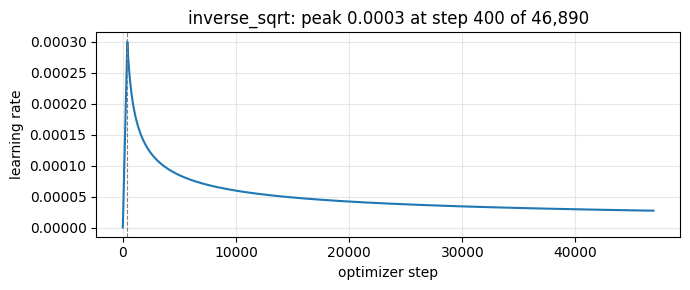

In [12]:
m = GPT.from_config(cfg, vocab.size)
print(m)
groups = {}
for name, p in m.named_parameters():
    key = "blocks (all layers)" if name.startswith("blocks.") else name.split(".")[0]
    groups[key] = groups.get(key, 0) + p.numel()
display(pd.DataFrame({"parameters": groups}).assign(
    share=lambda d: (d.parameters / d.parameters.sum()).round(3)))
print(f"total trainable parameters: {m.num_params():,}")

# Causality: changing the LAST input character must not change any earlier prediction.
m.eval()
g = torch.Generator().manual_seed(cfg.seed)
a = torch.randint(0, vocab.size, (1, cfg.block_size), generator=g)
b = a.clone(); b[0, -1] = (a[0, -1] + 1) % vocab.size
with torch.no_grad():
    la, lb = m(a), m(b)
print("\ncausality: max |change| at positions 0..T-2 =", (la[0, :-1] - lb[0, :-1]).abs().max().item(),
      "| at position T-1 =", round((la[0, -1] - lb[0, -1]).abs().max().item(), 4))
print("mask, first 8 x 8 positions (1 = may attend):")
print(m.blocks[0].attn.causal_mask[0, 0, :8, :8].int().numpy())
del m

total = cfg.epochs * math.ceil(cfg.train_sequences / cfg.batch_size)
steps = range(1, total + 1)
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(steps, [cfg.lr * lr_multiplier(s, cfg.warmup_steps, cfg.schedule) for s in steps])
ax.axvline(cfg.warmup_steps, ls="--", c="grey", lw=0.8)
ax.set_xlabel("optimizer step"); ax.set_ylabel("learning rate"); ax.grid(alpha=0.3)
ax.set_title(f"{cfg.schedule}: peak {cfg.lr:g} at step {cfg.warmup_steps} of {total:,}")
fig.tight_layout(); plt.show()

## 13. Train (brief 1.3)
- **Loss and optimiser:** cross-entropy, AdamW, inverse-square-root warmup and gradient clipping.
- **Logging:** every step goes to the raw log; every `log_every` steps and every epoch also show here.
- **Validation and checkpoints:** validation runs after each epoch. `gpt_best.pt` holds the epoch with the lowest validation CE;
  `gpt_last.pt` (for resume) is saved after every epoch.

In [13]:
STEP_FIELDS = ["step", "epoch", "loss", "lr", "grad_norm", "step_seconds", "elapsed_seconds", "peak_mem_gb"]


def save_plots(history: list[dict]) -> None:
    with open(STEPS_CSV, newline="", encoding="utf-8") as f:
        rows = list(csv.DictReader(f))
    s = [int(r["step"]) for r in rows]
    fig, ax = plt.subplots(figsize=(7, 4))
    ep = [h["epoch"] for h in history]
    ax.plot(ep, [h["train_ce"] for h in history], marker="o", label="train CE (epoch mean)")
    ax.plot(ep, [h["val_ce"] for h in history], marker="o", label="validation CE")
    ax.set_xlabel("epoch"); ax.set_ylabel("cross-entropy (nats / char)")
    ax.set_title("Task 1 loss curves"); ax.grid(alpha=0.3); ax.legend()
    fig.tight_layout(); fig.savefig(OUTPUTS / "loss_curve.png", dpi=150); plt.close(fig)
    fig, axes = plt.subplots(3, 1, figsize=(7, 8), sharex=True)
    for a, key, label in zip(axes, ["loss", "lr", "grad_norm"],
                             ["train loss", "learning rate", "pre-clip grad norm"]):
        a.plot(s, [float(r[key]) for r in rows], lw=0.8); a.set_ylabel(label); a.grid(alpha=0.3)
    axes[2].set_yscale("log"); axes[2].set_xlabel("optimizer step")
    fig.suptitle("Task 1 per-step training signals")
    fig.tight_layout(); fig.savefig(OUTPUTS / "train_steps.png", dpi=150); plt.close(fig)


def train(resume: bool) -> dict:
    set_seeds(cfg.seed)
    logger, log_path = open_run_log("train")
    try:
        snapshot_config(log_path)
        logger.info(f"source {SOURCE.name} bytes {SOURCE.stat().st_size} sha256 {DATA_SHA256}")
        logger.info(f"split offset_bytes {split['offset_bytes']} | {split['n_train']} train + "
                    f"{split['n_val']} val sequences of {split['seq_len']} chars | train "
                    f"{len(split['train_text'])} chars | val {len(split['val_text'])} chars")
        VOCAB_JSON.write_text(json.dumps(vocab.to_json(), ensure_ascii=False, indent=1), encoding="utf-8")
        val_unknown = vocab.count_unknown(split["val_text"])
        logger.info(f"vocab {vocab.size} ids ({len(vocab.chars)} chars + <unk>) | val chars as <unk>: {val_unknown}")

        loader_gen = torch.Generator().manual_seed(cfg.seed)
        train_loader = DataLoader(SequenceDataset(train_ids, split["seq_len"]), batch_size=cfg.batch_size,
                                  shuffle=True, generator=loader_gen)
        val_loader = DataLoader(SequenceDataset(val_ids, split["seq_len"]), batch_size=cfg.batch_size)
        steps_per_epoch = len(train_loader)
        total_steps = check_schedule(cfg, steps_per_epoch)
        logger.info(f"steps_per_epoch {steps_per_epoch} | total_steps {total_steps} | warmup_steps "
                    f"{cfg.warmup_steps} ({cfg.warmup_steps / total_steps:.2%} of training)")

        model = GPT.from_config(cfg, vocab.size).to(DEVICE)
        opt, n_decay, n_no_decay = build_optimizer(model, cfg)
        sched = torch.optim.lr_scheduler.LambdaLR(
            opt, lambda e: lr_multiplier(e + 1, cfg.warmup_steps, cfg.schedule))
        n_params = model.num_params()
        logger.info(f"params {n_params} | weight-decayed {n_decay} | not decayed {n_no_decay}")

        st = {"epoch": 0, "step": 0, "best_val": math.inf, "best_epoch": 0, "history": [],
              "nan_count": 0, "elapsed": 0.0, "compute_s": 0.0, "tokens": 0}
        kept = []
        if resume:
            ck = torch.load(LAST_CKPT, map_location=DEVICE, weights_only=False)
            if ck["config_sha256"] != CFG_HASH:
                logger.warning("resuming with different settings than the checkpoint")
            model.load_state_dict(ck["model"]); opt.load_state_dict(ck["optimizer"])
            sched.load_state_dict(ck["scheduler"]); loader_gen.set_state(ck["loader_gen"])
            set_rng_state(ck["rng"]); st = ck["state"]
            with open(STEPS_CSV, newline="", encoding="utf-8") as f:        # drop steps after the checkpoint
                kept = [r for r in csv.DictReader(f) if int(r["step"]) <= st["step"]]
            logger.info(f"resumed from {rel(LAST_CKPT)} at epoch {st['epoch']} step {st['step']}")

        reset_peak_mem()
        base_elapsed, t0 = st["elapsed"], time.perf_counter()
        with open(STEPS_CSV, "w", newline="", encoding="utf-8") as csv_file:
            writer = csv.DictWriter(csv_file, fieldnames=STEP_FIELDS)
            writer.writeheader(); writer.writerows(kept)
            for epoch in range(st["epoch"], cfg.epochs):
                model.train()
                ep_loss, ep_tokens = 0.0, 0
                for x, y in train_loader:
                    ts = time.perf_counter()
                    x, y = x.to(DEVICE), y.to(DEVICE)
                    lr = opt.param_groups[0]["lr"]            # the lr this step uses
                    logits = model(x)
                    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), y.view(-1))
                    opt.zero_grad(set_to_none=True)
                    loss_val = loss.item()
                    if math.isfinite(loss_val):
                        loss.backward()
                        # clip_grad_norm_ returns the norm BEFORE clipping: the stability metric
                        grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip).item()
                        if math.isfinite(grad_norm):
                            opt.step()
                        else:
                            st["nan_count"] += 1                # skip a poisoned update
                        ep_loss += loss_val * y.numel(); ep_tokens += y.numel()
                    else:
                        grad_norm = float("nan"); st["nan_count"] += 1
                    sched.step()
                    sync(DEVICE)
                    dt = time.perf_counter() - ts
                    st["step"] += 1; st["compute_s"] += dt; st["tokens"] += y.numel()
                    elapsed, pm = base_elapsed + time.perf_counter() - t0, peak_mem_gb()
                    writer.writerow({"step": st["step"], "epoch": epoch + 1, "loss": loss_val, "lr": lr,
                                     "grad_norm": grad_norm, "step_seconds": dt,
                                     "elapsed_seconds": elapsed, "peak_mem_gb": pm})
                    msg = (f"step {st['step']} epoch {epoch + 1} loss {loss_val:.4f} lr {lr:.3e} "
                           f"grad_norm {grad_norm:.4f} step_s {dt:.4f} elapsed_s {elapsed:.1f} peak_mem_gb {pm:.3f}")
                    (logger.info if st["step"] == 1 or st["step"] % cfg.log_every == 0 else logger.debug)(msg)

                val = evaluate_lm(model, val_loader, DEVICE)
                train_ce = ep_loss / ep_tokens if ep_tokens else float("nan")
                elapsed = base_elapsed + time.perf_counter() - t0
                st["history"].append({"epoch": epoch + 1, "step": st["step"], "train_ce": train_ce,
                                      "val_ce": val["ce"], "val_acc": val["acc"],
                                      "lr": opt.param_groups[0]["lr"], "elapsed_seconds": elapsed})
                logger.info(f"epoch {epoch + 1}/{cfg.epochs} train_ce {train_ce:.4f} val_ce {val['ce']:.4f} "
                            f"val_acc {val['acc']:.4f} gap {val['ce'] - train_ce:+.4f} nan_count {st['nan_count']}")
                if val["ce"] < st["best_val"]:
                    st["best_val"], st["best_epoch"] = val["ce"], epoch + 1
                    torch.save({"model": model.state_dict(), "config": dict(cfg), "config_sha256": CFG_HASH,
                                "vocab": vocab.to_json(), "epoch": epoch + 1, "step": st["step"],
                                "val_ce": val["ce"], "train_ce": train_ce}, BEST_CKPT)
                    logger.info(f"new best val_ce {val['ce']:.4f} -> {rel(BEST_CKPT)}")
                st["epoch"], st["elapsed"] = epoch + 1, elapsed
                torch.save({"model": model.state_dict(), "optimizer": opt.state_dict(),
                            "scheduler": sched.state_dict(), "loader_gen": loader_gen.get_state(),
                            "rng": rng_state(), "state": st, "config_sha256": CFG_HASH}, LAST_CKPT)
                csv_file.flush()

        summary = {"run_name": cfg.run_name, "device_name": device_name(DEVICE), "param_count": n_params,
                   "params_weight_decayed": n_decay, "params_not_decayed": n_no_decay,
                   "vocab_size": vocab.size, "split_offset_bytes": split["offset_bytes"],
                   "seq_len": split["seq_len"], "train_sequences": split["n_train"],
                   "val_sequences": split["n_val"], "train_chars": len(split["train_text"]),
                   "val_chars": len(split["val_text"]), "val_unknown_chars": val_unknown,
                   "steps_per_epoch": steps_per_epoch, "total_steps": total_steps,
                   "warmup_steps": cfg.warmup_steps, "nan_count": st["nan_count"],
                   "best_epoch": st["best_epoch"], "best_val_ce": st["best_val"],
                   "train_seconds": st["elapsed"],                  # wall clock incl. validation
                   "train_compute_seconds": st["compute_s"],        # optimizer steps only
                   "tokens_processed": st["tokens"],
                   "train_tokens_per_sec": st["tokens"] / st["compute_s"] if st["compute_s"] else 0.0,
                   "peak_mem_gb": peak_mem_gb(), "train_log": rel(log_path)}
        HISTORY.write_text(json.dumps(st["history"], indent=2), encoding="utf-8")
        SUMMARY.write_text(json.dumps(summary, indent=2), encoding="utf-8")
        save_plots(st["history"])
        logger.info("summary " + json.dumps(summary))
        return summary
    except BaseException:
        logger.exception("training stopped with an error")
        raise
    finally:
        close_run_log(logger)


summary = train(RESUME)

2026-10-01 22:07:33,766 | INFO | config_sha256 14ac093d038df9bbc2dda131a79b866b36825215bda19698f58e4929ccab05c6
2026-10-01 22:07:33,807 | INFO | git_sha unknown | notebook task1_llm/sneha/src/task1_llm_sneha.ipynb
2026-10-01 22:07:33,808 | INFO | device cuda | NVIDIA GeForce RTX 4090
2026-10-01 22:07:33,809 | INFO | torch 2.1.2 | cuda 12.1 | python 3.10.13 | platform Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.31
2026-10-01 22:07:33,865 | INFO | log_path reproducibility/raw_logs/sneha/task1_gpt_train_main_20261001T220733Z.log
2026-10-01 22:07:33,879 | INFO | source TinyStoriesV2-GPT4-train.txt bytes 2227753162 sha256 6418d412de72888f52b5142c761ac21a582f7d1166f0bfbdb5f03ccfdec90443
2026-10-01 22:07:33,879 | INFO | split offset_bytes 1785390952 | 100000 train + 10000 val sequences of 129 chars | train 12900000 chars | val 1290000 chars
2026-10-01 22:07:33,920 | INFO | vocab 88 ids (87 chars + <unk>) | val chars as <unk>: 3
2026-10-01 22:07:33,921 | INFO | steps_per_epoch 1

## 14. Generate (brief 1.3.5)
- **Samples:** `gen_samples` temperature samples, plus one greedy sample per prompt for comparison.
- **Reproducible:** sample *i* uses prompt *i* mod 5 and its own seed (seed + *i*).
- **Throughput:** generation speed is measured at batch size 1.

In [14]:
def load_checkpoint(path: Path):
    ck = torch.load(path, map_location=DEVICE, weights_only=False)
    v = CharVocab.from_json(ck["vocab"])
    model = GPT.from_config(ck["config"], v.size).to(DEVICE)
    model.load_state_dict(ck["model"])
    return model.eval(), v, ck


def generate_one(model, v, prompt, greedy, seed) -> dict:
    idx = v.encode(prompt).unsqueeze(0).to(DEVICE)
    gen = torch.Generator(device=DEVICE).manual_seed(seed)
    sync(DEVICE); t0 = time.perf_counter()
    out = model.generate(idx, cfg.gen_max_new_tokens, temperature=cfg.gen_temperature, greedy=greedy,
                         generator=gen, suppress_ids=[v.unk_index])
    sync(DEVICE)
    return {"prompt": prompt, "text": v.decode(out[0].tolist()),
            "continuation": v.decode(out[0, idx.size(1):].tolist()),
            "decoding": "greedy" if greedy else f"temperature {cfg.gen_temperature}",
            "seed": seed, "new_chars": cfg.gen_max_new_tokens, "seconds": time.perf_counter() - t0}


def generate_all() -> dict:
    set_seeds(cfg.seed)
    logger, log_path = open_run_log("generate")
    try:
        model, v, ck = load_checkpoint(BEST_CKPT)
        logger.info(f"checkpoint {rel(BEST_CKPT)} epoch {ck['epoch']} val_ce {ck['val_ce']:.4f}")
        prompts = cfg.gen_prompts
        for pr in prompts:
            if n := v.count_unknown(pr):
                logger.warning(f"prompt {pr!r} has {n} character(s) outside the vocabulary (fed as <unk>)")
        samples = [generate_one(model, v, prompts[i % len(prompts)], False, cfg.seed + i)
                   for i in range(cfg.gen_samples)]
        greedy = [generate_one(model, v, p, True, cfg.seed) for p in prompts] if cfg.gen_greedy_also else []
        total_s = sum(s["seconds"] for s in samples)
        result = {"checkpoint": rel(BEST_CKPT), "checkpoint_epoch": ck["epoch"],
                  "device_name": device_name(DEVICE), "batch_size": 1,
                  "gen_tokens_per_sec": sum(s["new_chars"] for s in samples) / total_s if total_s else 0.0,
                  "generate_log": rel(log_path), "samples": samples, "greedy": greedy}
        GEN_JSON.write_text(json.dumps(result, indent=1, ensure_ascii=False), encoding="utf-8")
        lines = [f"# Task 1 generations | {rel(BEST_CKPT)} (epoch {ck['epoch']}) | {cfg.gen_max_new_tokens} "
                 f"new chars each | batch size 1 | {result['gen_tokens_per_sec']:.1f} chars/sec on "
                 f"{result['device_name']}", ""]
        for i, s in enumerate(samples + greedy):
            tag = f"sample {i + 1:02d}" if i < len(samples) else f"greedy {i - len(samples) + 1:02d}"
            lines += [f"===== {tag} | {s['decoding']} | seed {s['seed']} | prompt: {s['prompt']!r}",
                      s["text"].replace(SEP, "\n<|endoftext|>\n"), ""]
        GEN_TXT.write_text("\n".join(lines), encoding="utf-8")
        logger.info(f"{len(samples)} samples + {len(greedy)} greedy -> {rel(GEN_TXT)} | "
                    f"gen_tokens_per_sec {result['gen_tokens_per_sec']:.1f}")
        return result
    except BaseException:
        logger.exception("generation stopped with an error")
        raise
    finally:
        close_run_log(logger)


gens = generate_all()

2026-10-01 22:22:02,708 | INFO | config_sha256 14ac093d038df9bbc2dda131a79b866b36825215bda19698f58e4929ccab05c6
2026-10-01 22:22:02,747 | INFO | git_sha unknown | notebook task1_llm/sneha/src/task1_llm_sneha.ipynb
2026-10-01 22:22:02,748 | INFO | device cuda | NVIDIA GeForce RTX 4090
2026-10-01 22:22:02,749 | INFO | torch 2.1.2 | cuda 12.1 | python 3.10.13 | platform Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.31
2026-10-01 22:22:02,802 | INFO | log_path reproducibility/raw_logs/sneha/task1_gpt_generate_main_20261001T222202Z.log
2026-10-01 22:22:02,982 | INFO | checkpoint task1_llm/sneha/checkpoints/gpt_best.pt epoch 30 val_ce 0.8024
2026-10-01 22:22:31,078 | INFO | 20 samples + 5 greedy -> task1_llm/sneha/outputs/generations.txt | gen_tokens_per_sec 435.9


## 15. Evaluate: every Task 1 metric in one row of `metrics_report.csv`, plus the manifest

| Column | Meaning |
|---|---|
| `train_ce` | Mean training CE of the best epoch (running mean, dropout on) |
| `train_ce_eval` | The best checkpoint's CE over all training sequences, in eval mode |
| `val_ce` | The best checkpoint's CE over all validation sequences, in eval mode |
| `gen_gap` | `val_ce − train_ce` |
| `gen_gap_eval` | The same, but with dropout off on both sides (a like-for-like comparison) |
| `final_*` | The same at the last epoch, so overfitting after the best epoch shows up |
| `train_tokens_per_sec` | Target characters ÷ seconds spent in optimizer steps |
| `gen_tokens_per_sec` | Generated characters ÷ generation seconds, at batch size 1 |

In [15]:
COLUMNS = ["train_ce", "val_ce", "perplexity", "bpc", "gen_gap", "top1_acc",
           "distinct_1", "distinct_2", "distinct_3", "rep_4gram",
           "grad_norm_max", "grad_norm_median", "loss_spikes", "nan_count", "param_count",
           "train_tokens_per_sec", "gen_tokens_per_sec", "peak_mem_gb", "train_seconds", "device_name",
           "train_ce_eval", "gen_gap_eval", "grad_norm_spikes", "best_epoch", "epochs_run",
           "final_train_ce", "final_val_ce", "final_gen_gap", "steps_per_epoch", "total_steps",
           "warmup_steps", "train_sequences", "val_sequences", "seq_len", "train_chars", "val_chars",
           "vocab_size", "checkpoint", "config_sha256"]


@torch.no_grad()
def evaluate_all() -> dict:
    t0 = time.perf_counter()
    logger, log_path = open_run_log("evaluate")
    try:
        model, v, ck = load_checkpoint(BEST_CKPT)
        s = json.loads(SUMMARY.read_text(encoding="utf-8"))
        history = json.loads(HISTORY.read_text(encoding="utf-8"))
        g = json.loads(GEN_JSON.read_text(encoding="utf-8"))
        assert g["checkpoint"] == rel(BEST_CKPT), "generations come from another checkpoint: rerun section 14"

        def loader(text):
            return DataLoader(SequenceDataset(v.encode(text), split["seq_len"]), batch_size=cfg.batch_size)
        val = evaluate_lm(model, loader(split["val_text"]), DEVICE)
        train_eval = evaluate_lm(model, loader(split["train_text"]), DEVICE)
        if abs(val["ce"] - ck["val_ce"]) > 1e-4:
            logger.warning(f"recomputed val_ce {val['ce']:.6f} differs from the checkpoint's {ck['val_ce']:.6f}")

        with open(STEPS_CSV, newline="", encoding="utf-8") as f:
            rows = list(csv.DictReader(f))
        losses, norms = [float(r["loss"]) for r in rows], [float(r["grad_norm"]) for r in rows]
        finite = [n for n in norms if math.isfinite(n)]
        texts = [x["continuation"] for x in g["samples"]]
        best = next(h for h in history if h["epoch"] == ck["epoch"])
        last = history[-1]
        row = {
            "train_ce": best["train_ce"], "val_ce": val["ce"], "perplexity": perplexity(val["ce"]),
            "bpc": bits_per_char(val["ce"]), "gen_gap": val["ce"] - best["train_ce"], "top1_acc": val["acc"],
            "distinct_1": distinct_n(texts, 1), "distinct_2": distinct_n(texts, 2),
            "distinct_3": distinct_n(texts, 3), "rep_4gram": repeated_4gram_rate(texts),
            "grad_norm_max": max(finite), "grad_norm_median": float(np.median(finite)),
            "loss_spikes": spike_count(losses, cfg.loss_spike_factor, cfg.spike_window),
            "nan_count": s["nan_count"], "param_count": model.num_params(),
            "train_tokens_per_sec": s["train_tokens_per_sec"], "gen_tokens_per_sec": g["gen_tokens_per_sec"],
            "peak_mem_gb": s["peak_mem_gb"], "train_seconds": s["train_seconds"], "device_name": s["device_name"],
            "train_ce_eval": train_eval["ce"], "gen_gap_eval": val["ce"] - train_eval["ce"],
            "grad_norm_spikes": spike_count(norms, cfg.grad_spike_factor, cfg.spike_window),
            "best_epoch": ck["epoch"], "epochs_run": last["epoch"],
            "final_train_ce": last["train_ce"], "final_val_ce": last["val_ce"],
            "final_gen_gap": last["val_ce"] - last["train_ce"],
            "steps_per_epoch": s["steps_per_epoch"], "total_steps": s["total_steps"],
            "warmup_steps": s["warmup_steps"], "train_sequences": s["train_sequences"],
            "val_sequences": s["val_sequences"], "seq_len": s["seq_len"], "train_chars": s["train_chars"],
            "val_chars": s["val_chars"], "vocab_size": s["vocab_size"],
            "checkpoint": rel(BEST_CKPT), "config_sha256": CFG_HASH}
        assert list(row) == COLUMNS
        with open(METRICS_CSV, "w", newline="", encoding="utf-8") as f:
            w = csv.DictWriter(f, fieldnames=COLUMNS); w.writeheader(); w.writerow(row)
        logger.info("metrics " + json.dumps(row))

        manifest = {
            "member": cfg.member, "task": "task1", "run_name": cfg.run_name, "config_sha256": CFG_HASH,
            "notebook": "task1_llm/sneha/src/task1_llm_sneha.ipynb", "git_sha": git_sha(), "seed": cfg.seed,
            "timestamp_utc": time.strftime("%Y-%m-%dT%H:%M:%SZ", time.gmtime()),
            "python": platform.python_version(), "platform": platform.platform(),
            "torch": torch.__version__, "cuda": torch.version.cuda, "device": device_name(DEVICE),
            "packages": installed_packages(), "duration_seconds": round(s["train_seconds"], 3),
            "data": {"file": rel(SOURCE), "sha256": DATA_SHA256, "split_offset_bytes": split["offset_bytes"]},
            "checkpoint": {"path": rel(BEST_CKPT), "sha256": sha256_file(BEST_CKPT),
                           "bytes": BEST_CKPT.stat().st_size},
            "metric_rows": {rel(BEST_CKPT): {"csv": rel(METRICS_CSV), "rows": [1]}},
            "raw_logs": [s["train_log"], g["generate_log"], rel(log_path)],
            "evidence": {k: rel(p) for k, p in {
                "loss_curve": OUTPUTS / "loss_curve.png", "train_steps_plot": OUTPUTS / "train_steps.png",
                "train_steps_csv": STEPS_CSV, "history": HISTORY, "generations": GEN_TXT,
                "vocab": VOCAB_JSON}.items()},
            "evaluate_seconds": round(time.perf_counter() - t0, 3),
            "config": dict(cfg)}
        MANIFEST.write_text(json.dumps(manifest, indent=2, ensure_ascii=False), encoding="utf-8")
        logger.info(f"wrote {rel(METRICS_CSV)} and {rel(MANIFEST)}")
        return row
    except BaseException:
        logger.exception("evaluation stopped with an error")
        raise
    finally:
        close_run_log(logger)


row = evaluate_all()

2026-10-01 22:22:31,092 | INFO | config_sha256 14ac093d038df9bbc2dda131a79b866b36825215bda19698f58e4929ccab05c6
2026-10-01 22:22:31,128 | INFO | git_sha unknown | notebook task1_llm/sneha/src/task1_llm_sneha.ipynb
2026-10-01 22:22:31,129 | INFO | device cuda | NVIDIA GeForce RTX 4090
2026-10-01 22:22:31,130 | INFO | torch 2.1.2 | cuda 12.1 | python 3.10.13 | platform Linux-6.18.33.2-microsoft-standard-WSL2-x86_64-with-glibc2.31
2026-10-01 22:22:31,183 | INFO | log_path reproducibility/raw_logs/sneha/task1_gpt_evaluate_main_20261001T222231Z.log
2026-10-01 22:22:43,463 | INFO | metrics {"train_ce": 0.8589187320327759, "val_ce": 0.802367117023468, "perplexity": 2.2308152843567126, "bpc": 1.157571060702132, "gen_gap": -0.05655161500930794, "top1_acc": 0.7476921875, "distinct_1": 0.2568674698795181, "distinct_2": 0.6545012165450121, "distinct_3": 0.8648648648648649, "rep_4gram": 0.01269838232322632, "grad_norm_max": 3.372800827026367, "grad_norm_median": 0.6949937641620636, "loss_spikes": 0

## 16. Results

In [16]:
pd.read_csv(METRICS_CSV).T.rename(columns={0: "value"})

,value
train_ce,0.858919
val_ce,0.802367
perplexity,2.230815
bpc,1.157571
gen_gap,-0.056552
top1_acc,0.747692
distinct_1,0.256867
distinct_2,0.654501
distinct_3,0.864865
rep_4gram,0.012698


,step,train_ce,val_ce,val_acc,lr,elapsed_seconds,gap
epoch,,,,,,,
1,1563,1.8973,1.2850,0.6069,0.0002,28.5150,-0.6123
2,3126,1.2749,1.1086,0.6586,0.0001,57.0731,-0.1663
3,4689,1.1564,1.0335,0.6798,0.0001,85.8622,-0.1229
4,6252,1.0963,0.9928,0.6918,0.0001,114.7786,-0.1035
5,7815,1.0575,0.9638,0.7001,0.0001,143.6234,-0.0937
6,9378,1.0295,0.9428,0.7063,0.0001,172.4783,-0.0867
7,10941,1.0083,0.9252,0.7120,0.0001,201.6698,-0.0830
8,12504,0.9908,0.9128,0.7154,0.0001,230.5047,-0.0779
9,14067,0.9763,0.8991,0.7196,0.0001,259.4556,-0.0772


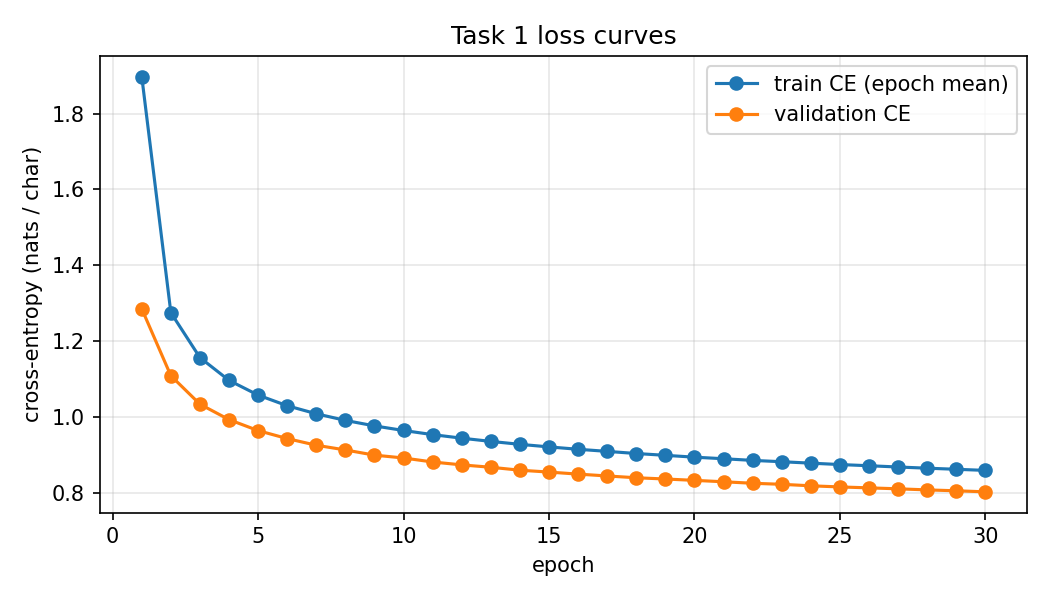

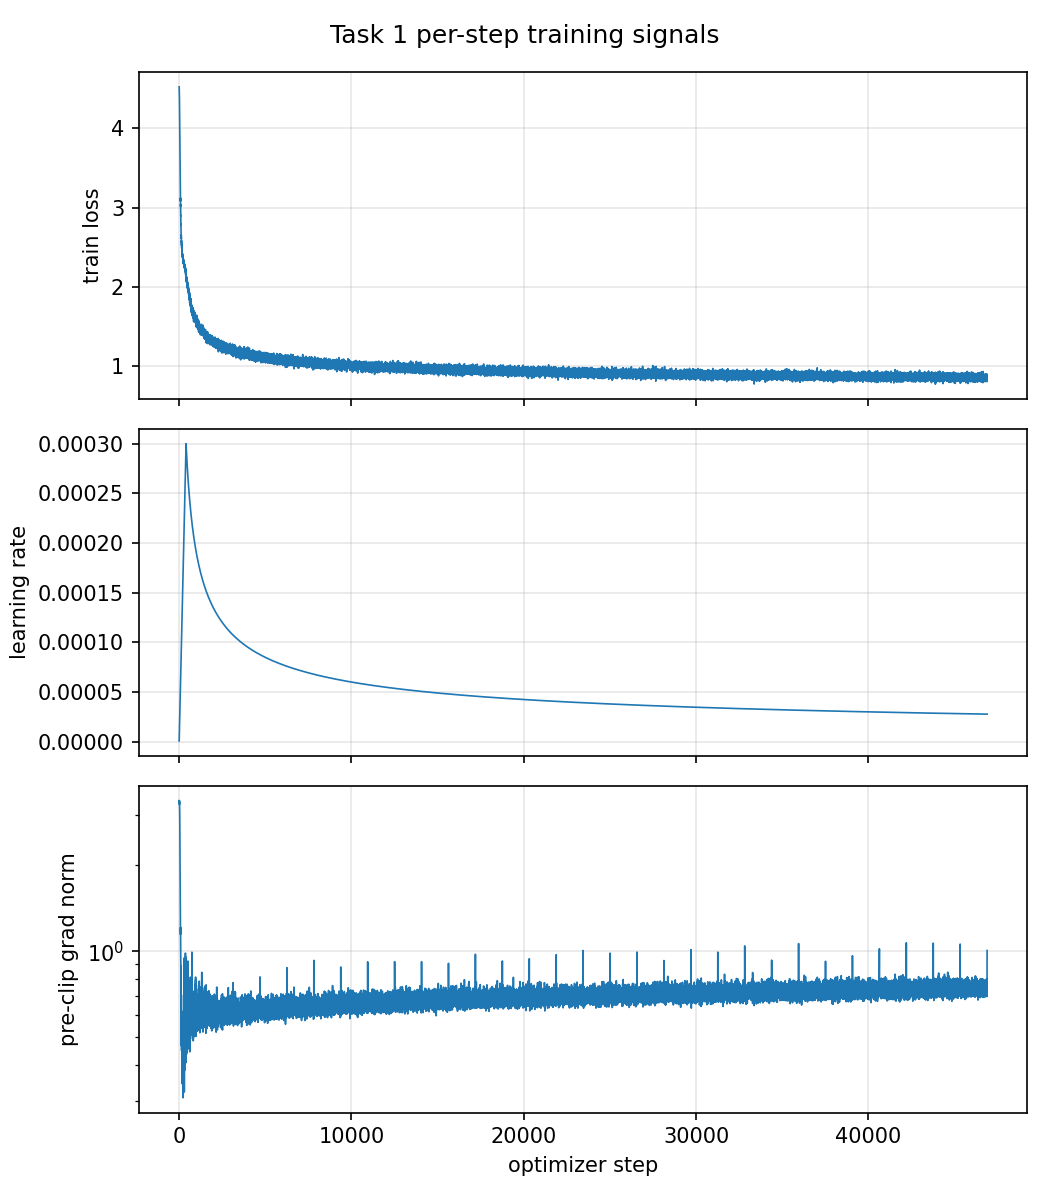

In [17]:
history = pd.DataFrame(json.loads(HISTORY.read_text(encoding="utf-8")))
history["gap"] = history.val_ce - history.train_ce
display(history.set_index("epoch").round(4))
display(Image(OUTPUTS / "loss_curve.png"))
display(Image(OUTPUTS / "train_steps.png"))

In [18]:
for s in gens["samples"][:5] + gens["greedy"]:
    print(f"===== {s['decoding']} | seed {s['seed']} | prompt {s['prompt']!r}")
    print(s["text"].replace(SEP, "\n<|endoftext|>\n"), "\n")
print(f"all {len(gens['samples'])} samples: {rel(GEN_TXT)}")

===== temperature 0.8 | seed 42 | prompt 'Once upon a time'
Once upon a time, in a small house, there was a graceful cat. The bird loved to run and said, "Good job, Tim. I made a loud noise." Tim looked around the cat and said, "My name is Sam. The cat is a great idea." He said, "Thank you, dog."
Tim and Sam felt sad. They played with the ball all day long. They wanted to play with it. They saw the ball and wanted to see the ball.
The ball was very sad and said, "Let's play with it all the music." The ball said, "I want to share the ball too!" The ball was so happy.
The 

===== temperature 0.8 | seed 43 | prompt 'One day, a little girl named'
One day, a little girl named Lily saw as the dog walked in the kitchen. She was very happy. She wanted to help each other and said, "Thank you, Tom. You are a magical boy."
The man smiled and said, "I have a fancy for you. The magic cat had a big bear. I need it was, but he was too shiny with his friends. They pretended to be friends and played wi

In [19]:
man = json.loads(MANIFEST.read_text(encoding="utf-8"))
print("manifest:", rel(MANIFEST))
print("device:", man["device"], "| torch", man["torch"], "| cuda", man["cuda"], "| git", man["git_sha"][:12])
print("data:", man["data"]["file"], "| sha256", man["data"]["sha256"][:16], "...")
print("checkpoint:", man["checkpoint"]["path"], "| sha256", man["checkpoint"]["sha256"][:16], "...")
print("raw logs:", *man["raw_logs"], sep="\n  ")

manifest: reproducibility/manifests/sneha_task1.json
device: NVIDIA GeForce RTX 4090 | torch 2.1.2 | cuda 12.1 | git unknown
data: task1_llm/data/TinyStoriesV2-GPT4-train.txt | sha256 6418d412de72888f ...
checkpoint: task1_llm/sneha/checkpoints/gpt_best.pt | sha256 05ba05a99e5879f2 ...
raw logs:
  reproducibility/raw_logs/sneha/task1_gpt_train_main_20261001T220733Z.log
  reproducibility/raw_logs/sneha/task1_gpt_generate_main_20261001T222202Z.log
  reproducibility/raw_logs/sneha/task1_gpt_evaluate_main_20261001T222231Z.log


## 17. Analysis
Written by me, not generated:
- **Architecture and hyperparameter justification:** [`../results.md`](../results.md)
- **Three failure cases:** [`../failure_analysis.md`](../failure_analysis.md)